# Notebook: Manejo, recorte y visualizaciónde archivos NetCDF

### Manejo y recorte de archivos (ERSST) con xarray

In [1]:
# Importar librerías
import os
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
# Definir la ruta y listar archivos NetCDF
path = "E:/bd/source/ersst_v6"

files = sorted([os.path.join(path, f) for f in os.listdir(path) if f.endswith(".nc")
])

print(f"Número de archivos encontrados: {len(files)}")
files[:10]

Número de archivos encontrados: 2108


['E:/bd/source/ersst_v6\\ersst.v6.185001.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185002.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185003.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185004.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185005.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185006.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185007.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185008.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185009.nc',
 'E:/bd/source/ersst_v6\\ersst.v6.185010.nc']

In [3]:
# Abrir múltiples NetCDF como un solo dataset
ds = xr.open_mfdataset(
    files,
    combine="by_coords", # une por coordenadas (p.ej., tiempo/lat/lon)
    compat="override",   # ignora diferencias menores entre archivos
    coords="minimal",    # evita conflictos innecesarios
    data_vars="minimal",
    engine="netcdf4"
)

ds

C:\Users\USER\anaconda3\lib\site-packages\xarray\backends\plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
No module named 'pooch'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset> Size: 270MB
Dimensions:  (time: 2108, lev: 1, lat: 89, lon: 180)
Coordinates:
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lev      (lev) float64 8B 0.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2025-08-15
Data variables:
    sst      (time, lev, lat, lon) float32 135MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
    ssta     (time, lev, lat, lon) float32 135MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    metadata_link:                   gov.noaa.ncei:C01737
    id:                              ersst.v6.185001.nc
    naming_authority:                gov.noaa.ncei
    title:                           NOAA monthly ERSSTv6 (in situ only)
    summary:                         Monthly ERSSTv6 is developed based on v5...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    references:                      Huang, B., X. Yin, T. Boyer, C. Liu, M. ...
    climatology:                     Climatology is based on 1991-2020 SST of...
    acknowledgment:                  The NOAA Extended Reconstructed Sea Surf...
    NCO:                             netCDF Operators version 5.0.7 (Homepage...
    history:                         Fri May  2 13:50:32 2025: ncap2 -O -s ti...

⚠️ Si esto falla → casi siempre es problema de coordenadas inconsistentes.

In [4]:
ds["sst"]

<xarray.DataArray 'sst' (time: 2108, lev: 1, lat: 89, lon: 180)> Size: 135MB
dask.array<concatenate, shape=(2108, 1, 89, 180), dtype=float32, chunksize=(1, 1, 89, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lev      (lev) float64 8B 0.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2025-08-15
Attributes:
    long_name:      Extended reconstructed sea surface temperature
    standard_name:  sea_surface_temperature
    units:          degree_C
    valid_min:      -3.0
    valid_max:      45.0

In [5]:
# Verificación del rango temporal (control de calidad)
time = pd.DatetimeIndex(ds["time"].values)

expected = (
    pd.date_range("1850-01-15", "2025-08-15", freq="MS")
    + pd.Timedelta(days=14)
)

missing = expected.difference(time)

print(f"Primer mes disponible: {time.min().strftime('%Y-%m')}")
print(f"Último mes disponible: {time.max().strftime('%Y-%m')}")

if len(missing) == 0:
    print("Todos los meses están presentes")
else:
    print(f"Faltan {len(missing)} meses")
    print(missing[:10])


Primer mes disponible: 1850-01
Último mes disponible: 2025-08
Todos los meses están presentes


⚠️ Nunca asumas que una serie temporal está completa.

> Busca hacer ciencia reproducible, no solo programación.

In [6]:
# Definir región geográfica de interés (Pacífico Nororiental)
lat_min, lat_max = 20, 55
lon_min, lon_max = -140, -105

# Ajustar longitudes del dataset
ds = ds.assign_coords(
    lon=((ds["lon"] + 180) % 360) - 180
).sortby("lon")
ds

<xarray.Dataset> Size: 270MB
Dimensions:  (time: 2108, lev: 1, lat: 89, lon: 180)
Coordinates:
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lev      (lev) float64 8B 0.0
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2025-08-15
  * lon      (lon) float64 1kB -180.0 -178.0 -176.0 -174.0 ... 174.0 176.0 178.0
Data variables:
    sst      (time, lev, lat, lon) float32 135MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
    ssta     (time, lev, lat, lon) float32 135MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    metadata_link:                   gov.noaa.ncei:C01737
    id:                              ersst.v6.185001.nc
    naming_authority:                gov.noaa.ncei
    title:                           NOAA monthly ERSSTv6 (in situ only)
    summary:                         Monthly ERSSTv6 is developed based on v5...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    references:                      Huang, B., X. Yin, T. Boyer, C. Liu, M. ...
    climatology:                     Climatology is based on 1991-2020 SST of...
    acknowledgment:                  The NOAA Extended Reconstructed Sea Surf...
    NCO:                             netCDF Operators version 5.0.7 (Homepage...
    history:                         Fri May  2 13:50:32 2025: ncap2 -O -s ti...

⚠️ El ERSST usa longitudes en el rango de 0–360, al igual que muchos productos climáticos

In [7]:
# Elimina dimensiones de tamaño 1 (p.ej., lev)
print(ds["sst"].shape)
sst = ds["sst"].squeeze()
ds.close()

sst

(2108, 1, 89, 180)


<xarray.DataArray 'sst' (time: 2108, lat: 89, lon: 180)> Size: 135MB
dask.array<getitem, shape=(2108, 89, 180), dtype=float32, chunksize=(1, 89, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
    lev      float64 8B 0.0
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2025-08-15
  * lon      (lon) float64 1kB -180.0 -178.0 -176.0 -174.0 ... 174.0 176.0 178.0
Attributes:
    long_name:      Extended reconstructed sea surface temperature
    standard_name:  sea_surface_temperature
    units:          degree_C
    valid_min:      -3.0
    valid_max:      45.0

In [8]:
# Recorte por latitud y longitud
sst = sst.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max),
    # time=slice("2000-01-01", "2020-12-31"),
)
sst

<xarray.DataArray 'sst' (time: 2108, lat: 18, lon: 18)> Size: 3MB
dask.array<getitem, shape=(2108, 18, 18), dtype=float32, chunksize=(1, 18, 18), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 144B 20.0 22.0 24.0 26.0 28.0 ... 48.0 50.0 52.0 54.0
    lev      float64 8B 0.0
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2025-08-15
  * lon      (lon) float64 144B -140.0 -138.0 -136.0 ... -110.0 -108.0 -106.0
Attributes:
    long_name:      Extended reconstructed sea surface temperature
    standard_name:  sea_surface_temperature
    units:          degree_C
    valid_min:      -3.0
    valid_max:      45.0

In [9]:
# Guardar datos recortados en NetCDF
sst.to_netcdf("E:/bd/source/ersst_v6/ersst_v6_nep.nc")
del sst

# Abrir el nuevo NetCDF
ds = xr.open_dataset("E:/bd/source/ersst_v6/ersst_v6_nep.nc")
ds

<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 18, time: 2108, lon: 18)
Coordinates:
  * lat      (lat) float64 144B 20.0 22.0 24.0 26.0 28.0 ... 48.0 50.0 52.0 54.0
    lev      float64 8B ...
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2025-08-15
  * lon      (lon) float64 144B -140.0 -138.0 -136.0 ... -110.0 -108.0 -106.0
Data variables:
    sst      (time, lat, lon) float32 3MB ...

### Visualización espacial y temporal de los datos

In [10]:
# Importar librerías
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

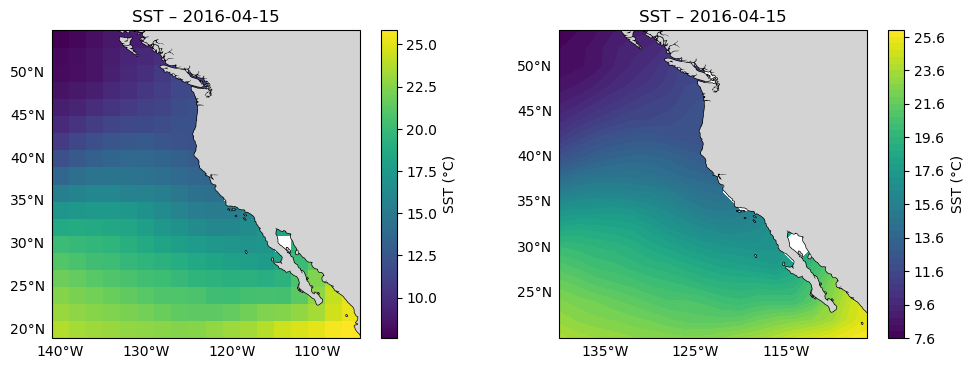

In [11]:
# Seleccionar una fecha
sst = ds.sel(time="2016-04-15")

# Graficar con matplotlib y Cartopy
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, color="none")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title("SST – 2016-04-15")

pc = ax1.pcolor(sst.lon, sst.lat, sst.sst, transform=ccrs.PlateCarree())
fig.colorbar(pc, ax=ax1, label="SST (°C)")

pc = ax2.contourf(sst.lon, sst.lat, sst.sst, levels=50, transform=ccrs.PlateCarree())
fig.colorbar(pc, ax=ax2, label="SST (°C)")

plt.show()

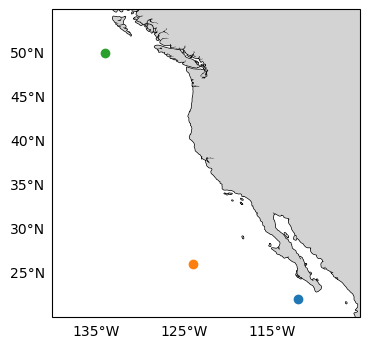

In [12]:
# Definir puntos
points = {
    "Punto A": {"lat": 22.0, "lon": -112.0},
    "Punto B": {"lat": 25.0, "lon": -125.0},
    "Punto C": {"lat": 50.0, "lon": -135.0},
}

# Extraer las series de tiempo (nearest)
series = {}
for name, p in points.items():
    series[name] = ds.sel(
        lat=p["lat"],
        lon=p["lon"],
        method="nearest"
    )
    
# Graficar puntos
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.coastlines()
gl = ax.gridlines(draw_labels=True, color="none")
gl.top_labels = False
gl.right_labels = False

for name, da in series.items():
    ax.scatter(da.lon, da.lat, transform=ccrs.PlateCarree())
    
plt.show()

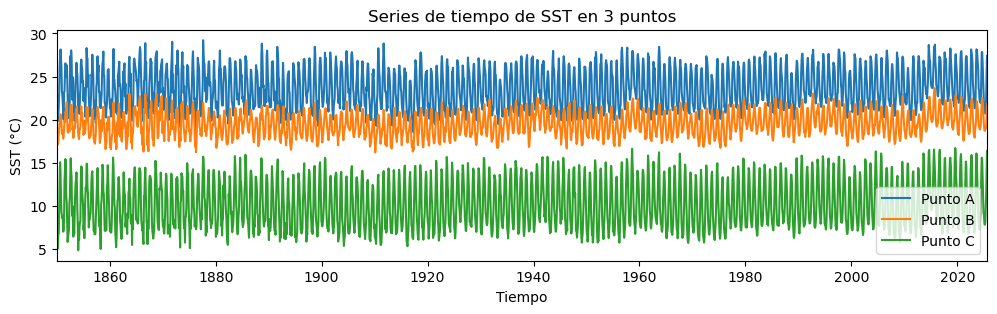

In [13]:
# Graficar series de tiempo
fig, ax = plt.subplots(figsize=(12, 3))

for name, da in series.items():
    ax.plot(da.time, da.sst, label=name)

ax.set_xlim(da.time[0], da.time[-1])
ax.set_xlabel("Tiempo")
ax.set_ylabel("SST (°C)")
ax.legend()
ax.set_title("Series de tiempo de SST en 3 puntos")
plt.show()

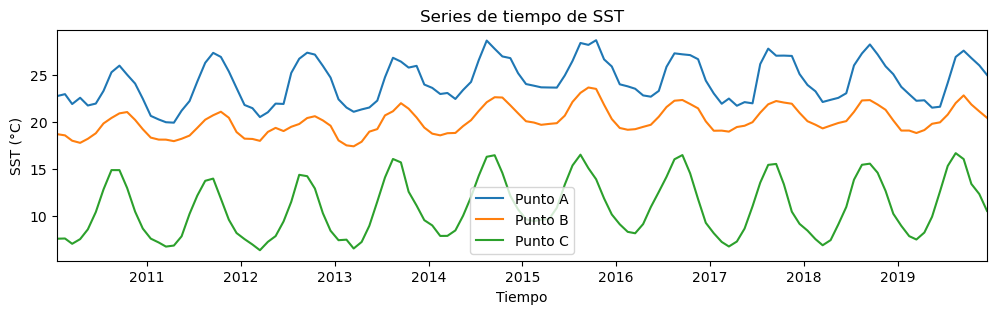

In [14]:
# Graficar series de tiempo
fig, ax = plt.subplots(figsize=(12, 3))

for name, da in series.items():
    # Recortar serie de tiempo
    da = da.sel(
        time=slice("2010-01-01", "2019-12-31"),
    )
    ax.plot(da.time, da.sst, label=name)

ax.set_xlim(da.time[0], da.time[-1])
ax.set_xlabel("Tiempo")
ax.set_ylabel("SST (°C)")
ax.legend()
ax.set_title("Series de tiempo de SST")
plt.show()